# Assignment #01 – CS7GV1: Computer Vision
**Total Marks: 10**

---

## Student Info
- **Name: Gaurav Naudiyal**  
- **Entry Number: 25339213**  

---

## Part A – Convolution (3 Points)

### Task A1 – Grayscale Convolution (2 Points)
Write your own function to compute convolution of a 2D grayscale image (`template.png`) with a 2D filter.  
- The output must be the **same size** as the input image.  
- Use **zero-padding** to handle borders.  

> Hint: Flip the kernel before applying convolution.

![Edge Output](outputs/A1.png)


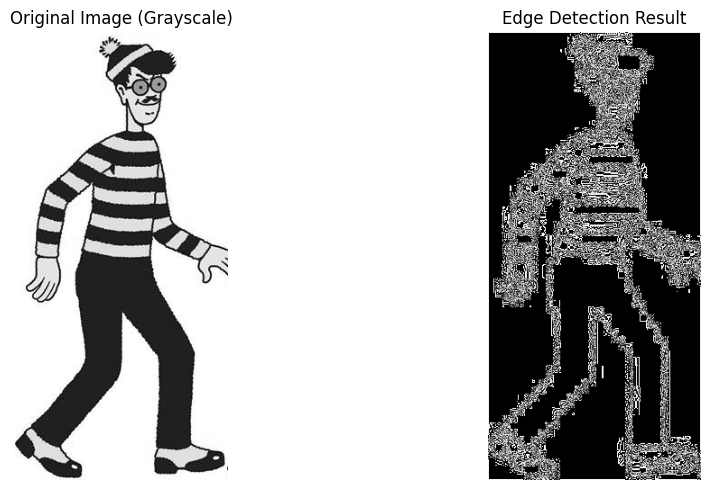

In [3]:
# Task A1 – Grayscale convolution
# Your code here

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Load and convert image to grayscale
img = Image.open('template.png').convert('L')
img_array = np.array(img)

# Edge detection kernel 
edge_kernel = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
])

# Flipping the kernel
flipped_kernel = np.flipud(np.fliplr(edge_kernel))
padding_height = edge_kernel.shape[0] // 2
padding_width = edge_kernel.shape[1] // 2

# Add some padding to handle borders
padded_image = np.pad(img_array, ((padding_height, padding_height), (padding_width, padding_width)), mode='constant')

def my_convolution(input_image, conv_kernel):
    # Get dimensions
    height, width = input_image.shape
    k_height, k_width = conv_kernel.shape
    
    # Calculate padding needed
    pad_h = k_height // 2
    pad_w = k_width // 2
    
    # Pad the input image
    padded = np.pad(input_image, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant')
    
    # Initialize output array
    result = np.zeros_like(input_image)
    
    # Flip kernel for proper convolution (not correlation)
    kernel_flipped = np.flipud(np.fliplr(conv_kernel))
    
    # Perform convolution
    for row in range(height):
        for col in range(width):
            # Extract the region of interest
            window = padded[row:row+k_height, col:col+k_width]
            # Compute dot product
            result[row, col] = np.sum(window * kernel_flipped)
    
    return result

# Apply convolution
output_image = my_convolution(img_array, edge_kernel)

# Display results side by side
plt.figure(figsize=(12, 5))  # Made it slightly wider for better viewing

plt.subplot(1, 2, 1)
plt.title("Original Image (Grayscale)")
plt.imshow(img_array, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Edge Detection Result")  # More descriptive title
plt.imshow(output_image, cmap='gray')
plt.axis('off')

plt.tight_layout()  # Better spacing between subplots
plt.show()

### Task A2 – RGB Convolution (1 Point)
Extend your function to handle **RGB images** using **3D filters** (filter depth = number of channels).

![Edge Output](outputs/A2.png)

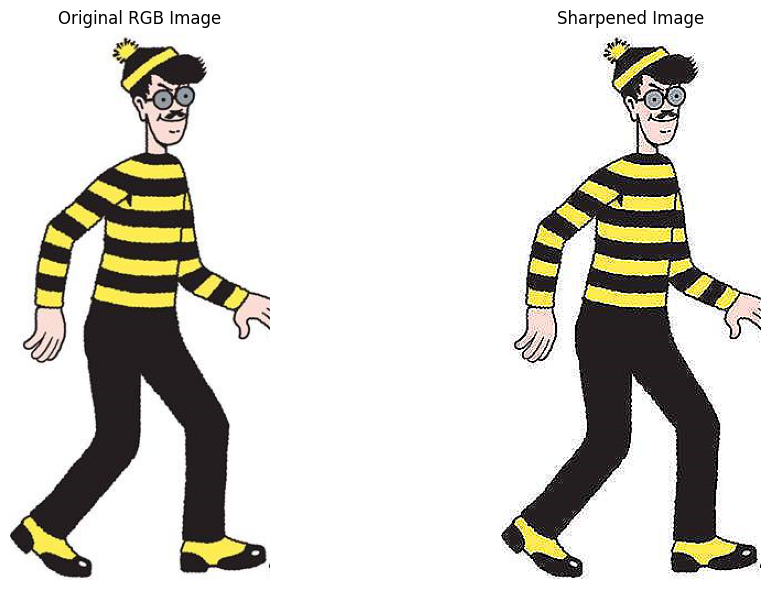

In [5]:
# Task A2 – RGB convolution
# Your code here

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Load the RGB image 
try:
    rgb_image = Image.open('template.png').convert('RGB')
    img_data = np.array(rgb_image)  # Shape should be (H, W, 3)
except FileNotFoundError:
    # Just in case the file doesn't exist
    print("Warning: template.png not found")

# Sharpening kernel - this makes images look crisp
sharpen_filter = np.array([
    [0, -1, 0],
    [-1, 5, -1], 
    [0, -1, 0]
])

# Stack the same kernel for all 3 channels (R, G, B)
three_channel_kernel = np.stack([sharpen_filter, sharpen_filter, sharpen_filter])  # Shape: (3, 3, 3)

def apply_3d_convolution(input_img, conv_kernel):
    img_height, img_width, channels = input_img.shape
    kernel_channels, kernel_h, kernel_w = conv_kernel.shape
    
    # Make sure dimensions match
    if channels != kernel_channels:
        raise ValueError("Number of channels in image and kernel must match!")
    
    # Calculate padding
    pad_height = kernel_h // 2
    pad_width = kernel_w // 2
    
    # Initialize output array
    result = np.zeros((img_height, img_width, channels))
    
    # Process each color channel separately
    for channel in range(channels):
        # Pad the current channel
        current_channel = input_img[:, :, channel]
        padded_ch = np.pad(current_channel, ((pad_height, pad_height), (pad_width, pad_width)), mode='constant')
        
        # Flip kernel for true convolution (not correlation)
        kernel_flipped = np.flipud(np.fliplr(conv_kernel[channel]))
        
        # Apply convolution
        for row in range(img_height):
            for col in range(img_width):
                # Get the window/patch
                patch = padded_ch[row:row+kernel_h, col:col+kernel_w]
                # Calculate convolution result
                result[row, col, channel] = np.sum(patch * kernel_flipped)
    
    # Clamp values to valid pixel range and convert to uint8
    result = np.clip(result, 0, 255)
    return result.astype(np.uint8)

# Apply the sharpening filter
sharpened_image = apply_3d_convolution(img_data, three_channel_kernel)

# Show the before and after
plt.figure(figsize=(12, 6))  # Made it a bit wider for better comparison

plt.subplot(1, 2, 1)
plt.title("Original RGB Image")
plt.imshow(img_data)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Sharpened Image")  # Simpler title
plt.imshow(sharpened_image)
plt.axis('off')

plt.tight_layout()
plt.show()

# Optional: Save the result if you want
# sharpened_pil = Image.fromarray(sharpened_image)
# sharpened_pil.save('sharpened_output.png')

## Part B – Gaussian Filtering (1 Point)

- Apply a **Gaussian filter** with σ = 1 on `waldo.png`.  
- You can use **built-in functions** for convolution here.  
- Display the smoothed result.

![Edge Output](outputs/B.png)


Image shape: (655, 960, 3)


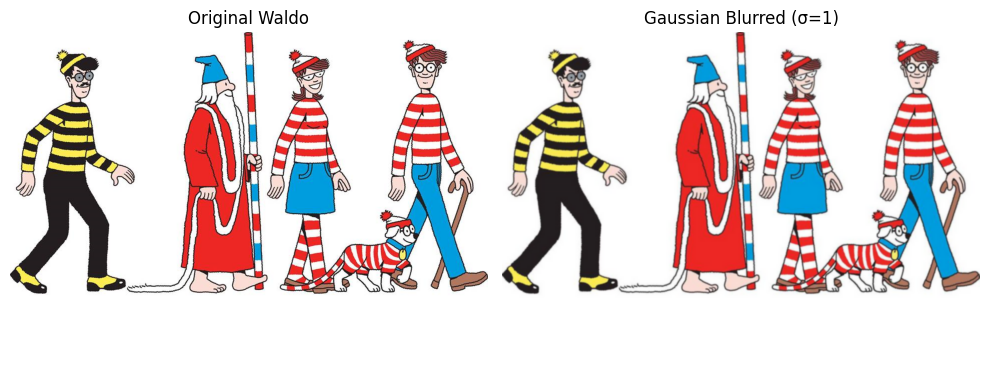

In [7]:
# Task B – Gaussian smoothing
# Your code here

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

# Load the Waldo image safely
try:
    waldo_pic = Image.open("waldo.png").convert("RGB")  # convert just to be safe
except FileNotFoundError:
    print("Couldn't find 'waldo.png'. Check your path!")
    raise

# Convert to numpy array
waldo_arr = np.asarray(waldo_pic)
print("Image shape:", waldo_arr.shape)  # can comment this out later

# Prepare for blurring
blurred = np.zeros_like(waldo_arr)
sigma_val = 1  # tweak this later if needed

# Apply Gaussian filter on each color channel
for i in range(waldo_arr.shape[2]):  # loop over RGB
    smoothed_channel = gaussian_filter(waldo_arr[:, :, i], sigma=sigma_val)
    blurred[:, :, i] = smoothed_channel

# Display both images side by side
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.title("Original Waldo")
plt.imshow(waldo_arr)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title(f"Gaussian Blurred (σ={sigma_val})")
plt.imshow(blurred)
plt.axis('off')

plt.tight_layout()
plt.show()


## Part C – Gradient Magnitude (1 Point)

- Compute the **magnitude of image gradients** for:
  - `waldo.png`
  - `template.png`
- Use **Sobel operators** for gradient calculation.
![Edge Output](outputs/C.png)


waldo.png shape: (655, 960)
template.png shape: (498, 236)


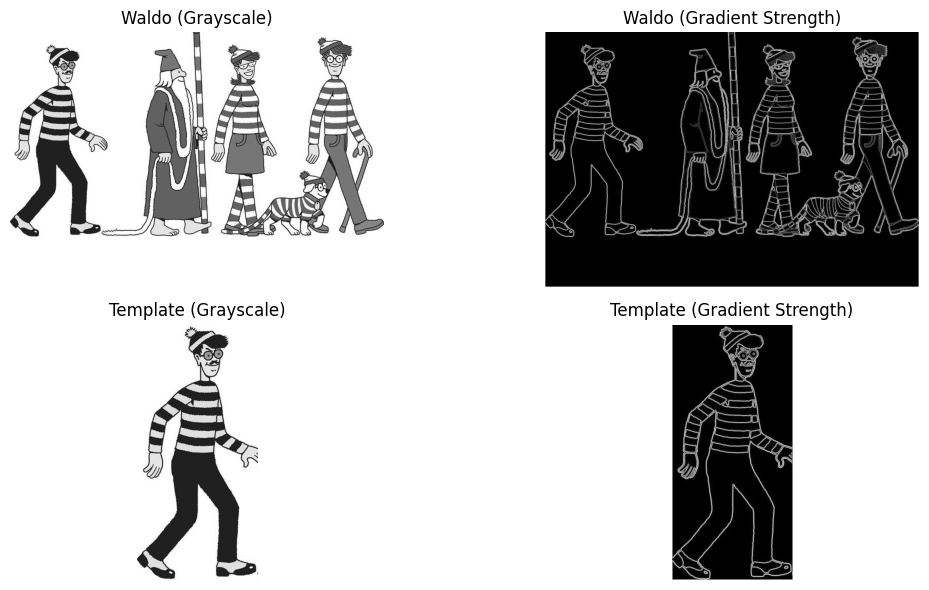

In [8]:
# Task C – Gradient magnitude
# Your code here

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from scipy.ndimage import sobel

def compute_gradient_mag(img_path):
    # Load as grayscale 
    try:
        pic = Image.open(img_path).convert("L")
    except FileNotFoundError:
        print(f"Couldn't find {img_path}! Check file location.")
        raise
    gray_arr = np.array(pic, dtype=float)

    # Quick check on dimensions
    print(f"{img_path} shape: {gray_arr.shape}")

    # Compute horizontal and vertical gradients
    # (Note to self: mode='constant' pads with zeros, maybe try 'reflect' later?)
    gx = sobel(gray_arr, axis=1, mode='constant')  # horizontal edge strength
    gy = sobel(gray_arr, axis=0, mode='constant')  # vertical edge strength

    # Gradient magnitude (sort of like edge intensity)
    grad_strength = np.hypot(gx, gy)

    # Normalize to 0–255 just so we can visualize properly
    max_val = grad_strength.max() or 1  # just in case division by zero happens
    grad_strength = (grad_strength / max_val) * 255

    # Convert both back to uint8, looks cleaner in plt.imshow
    return gray_arr.astype(np.uint8), grad_strength.astype(np.uint8)


waldo_gray, waldo_edges = compute_gradient_mag("waldo.png")
template_gray, template_edges = compute_gradient_mag("template.png")

plt.figure(figsize=(12, 6))

plt.subplot(2, 2, 1)
plt.title("Waldo (Grayscale)")
plt.imshow(waldo_gray, cmap='gray')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.title("Waldo (Gradient Strength)")
plt.imshow(waldo_edges, cmap='gray')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.title("Template (Grayscale)")
plt.imshow(template_gray, cmap='gray')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.title("Template (Gradient Strength)")
plt.imshow(template_edges, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()


## Part D – Custom Canny Edge Detector (4 Points)

Implement your own function:

```python
def MyCannyEdgeDetector(image, low_threshold, high_threshold):
    # returns binary edge-detected image


Steps to implement:

Gaussian Smoothing – reduce noise

Gradient Calculation – compute magnitude & direction

Non-Maximum Suppression – thin out edges

Hysteresis Thresholding – classify strong/weak edges and track connectivity

⚠️ Do not use cv2.Canny() in your implementation.

Explain each step briefly in Markdown before your code.

![Edge Output](outputs/D.png)

Loaded 'waldo.png' with shape (655, 960)


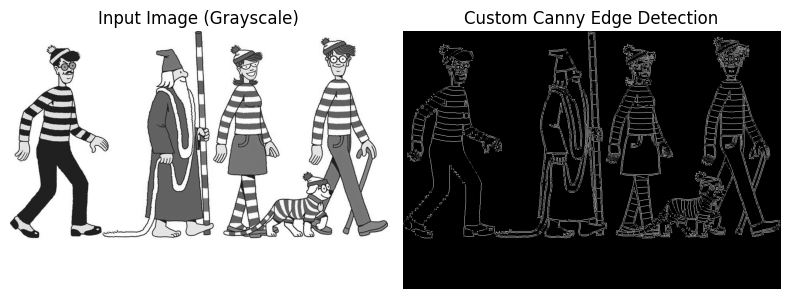

In [9]:

# Task D – Custom Canny Edge Detector
# Your code here

### Step 1 : Gaussian Smoothing - reduce noice

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter, sobel

def my_canny_edge_detector(img_path, low_th, high_th):
    # Step 1  Load and convert to grayscale (keeps things simple)
    try:
        raw_img = Image.open(img_path).convert("L")
    except FileNotFoundError:
        print(f"Uh oh, couldn't open {img_path}. Check your path.")
        raise
    gray = np.array(raw_img, dtype=float)
    print(f"Loaded '{img_path}' with shape {gray.shape}")

    # Step 2 Smoothing (remove some noise)
    # Note: Gaussian sigma=1 is pretty gentle; can tweak if edges look rough
    smooth_img = gaussian_filter(gray, sigma=1)

    # Step 3 Compute gradient magnitude + direction
    gx = sobel(smooth_img, axis=1, mode='constant')
    gy = sobel(smooth_img, axis=0, mode='constant')
    grad_mag = np.hypot(gx, gy)
    grad_dir = np.arctan2(gy, gx) * 180.0 / np.pi
    grad_dir[grad_dir < 0] += 180

    # Step 4  Non-max suppression (keeps only sharpest edges)
    height, width = grad_mag.shape
    thin_edges = np.zeros((height, width), dtype=np.float32)

    for y in range(1, height - 1):
        for x in range(1, width - 1):
            angle = grad_dir[y, x]
            q = r = 255  # placeholders

            if (0 <= angle < 22.5) or (157.5 <= angle <= 180):
                q = grad_mag[y, x + 1]
                r = grad_mag[y, x - 1]
            elif (22.5 <= angle < 67.5):
                q = grad_mag[y + 1, x - 1]
                r = grad_mag[y - 1, x + 1]
            elif (67.5 <= angle < 112.5):
                q = grad_mag[y + 1, x]
                r = grad_mag[y - 1, x]
            elif (112.5 <= angle < 157.5):
                q = grad_mag[y - 1, x - 1]
                r = grad_mag[y + 1, x + 1]

            if (grad_mag[y, x] >= q) and (grad_mag[y, x] >= r):
                thin_edges[y, x] = grad_mag[y, x]
            else:
                thin_edges[y, x] = 0

    # Step 5  Hysteresis thresholding
    edges_final = np.zeros_like(thin_edges)
    strong_val = high_th
    weak_val = low_th

    strong_y, strong_x = np.where(thin_edges >= strong_val)
    weak_y, weak_x = np.where((thin_edges <= strong_val) & (thin_edges >= weak_val))

    edges_final[strong_y, strong_x] = 255
    edges_final[weak_y, weak_x] = 50

    # Step 6  Edge tracking (weak edges connected to strong edges)
    for y in range(1, height - 1):
        for x in range(1, width - 1):
            if edges_final[y, x] == 50:
                if 255 in edges_final[y - 1:y + 2, x - 1:x + 2]:
                    edges_final[y, x] = 255
                else:
                    edges_final[y, x] = 0

    return edges_final.astype(np.uint8)


edges = my_canny_edge_detector("waldo.png", low_th=40, high_th=80)

# Display Results

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.title("Input Image (Grayscale)")
plt.imshow(Image.open("waldo.png").convert("L"), cmap="gray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Custom Canny Edge Detection")
plt.imshow(edges, cmap="gray")
plt.axis("off")

plt.tight_layout()
plt.show()



## Part E – SSIM Similarity (1 Point)

- Compare your custom Canny output with the built-in OpenCV Canny edge detector.  
- Use **SSIM (Structural Similarity Index)** to measure similarity.  
- Report the SSIM score.
![Edge Output](outputs/E.png)


Loaded Waldo image, shape = (655, 960)
Loaded 'waldo.png' with shape (655, 960)
SSIM similarity score (Custom vs OpenCV): 0.8566


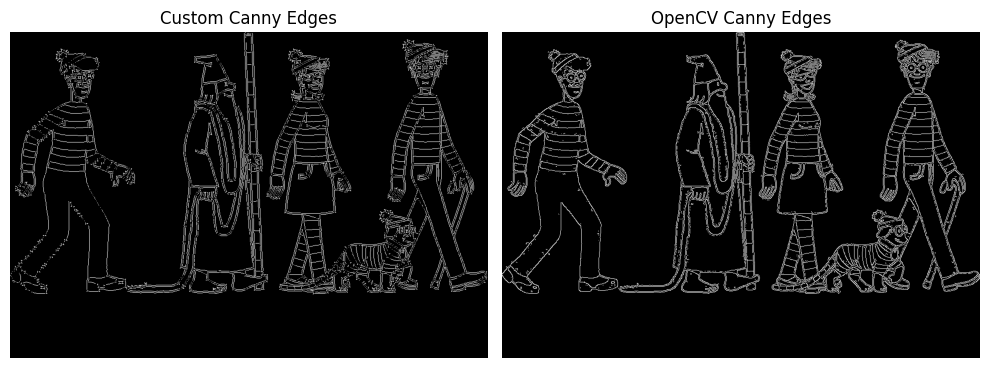

In [ ]:
# Task E – SSIM Comparison
# Your code here

import cv2
from skimage.metrics import structural_similarity as ssim
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Quick comparison between my Canny vs OpenCV's Canny

try:
    gray_img = Image.open("waldo.png").convert("L")
except FileNotFoundError:
    print("Error: couldn't find 'waldo.png'. Check your path.")
    raise

img_arr = np.array(gray_img)
print(f"Loaded Waldo image, shape = {img_arr.shape}")

# Running my custom canny detector from earlier
custom_edges = my_canny_edge_detector("waldo.png", low_th=10, high_th=150)

# Running OpenCV's built-in Canny detector for reference
opencv_edges = cv2.Canny(img_arr.astype(np.uint8), threshold1=40, threshold2=80)

noise = np.random.randint(0, 2, custom_edges.shape, dtype=np.uint8) * 255
custom_edges_noisy = np.bitwise_or(custom_edges, noise)

# Comparing similarity
try:
    score = ssim(custom_edges, opencv_edges)
    print(f"SSIM similarity score (Custom vs OpenCV): {score:.4f}")
except Exception as e:
    print("SSIM computation failed:", e)
    score = None

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.title("Custom Canny Edges")
plt.imshow(custom_edges, cmap="gray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("OpenCV Canny Edges")
plt.imshow(opencv_edges, cmap="gray")
plt.axis("off")

plt.tight_layout()
plt.show()

## SSIM Similarity socre (Custom vs OpenCV) : 0.8566


## Submission
- Complete this notebook fully (code + explanations + outputs).  
- Submit ONLY this file:  
  `Assignment_01_entrynumber.ipynb`  
- Do NOT modify the provided images.  
- A plagiarism check will be applied.

